In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

✅ Successfully loaded data!
   Rows (Envs): 57344
   Columns:     4929
✅ Fixed 'gt_fric_force' column types.

--- Target Property Distributions ---


NameError: name 'PLOT_SHOW' is not defined

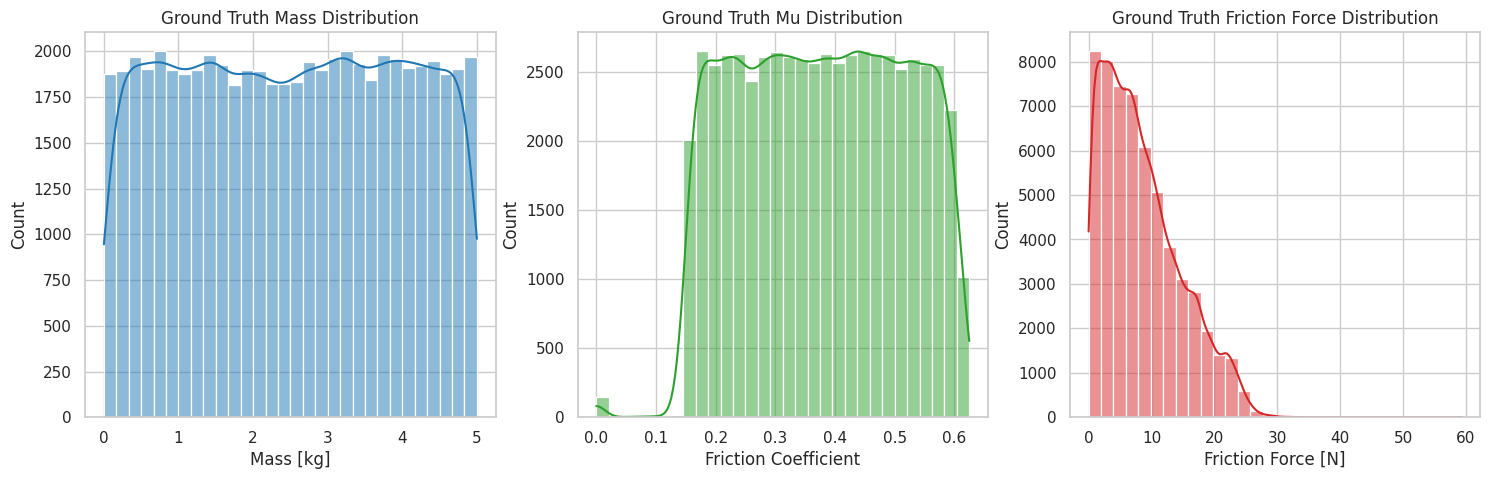

In [2]:

# ==========================================
# 1. CONFIGURATION
# ==========================================
# CSV_PATH = "/home/psxkf4/IsaacLab/source/collected_data/data_tb-3_ta57_emavel1.0_velstd0.0.csv"
CSV_PATH = "/home/psxkf4/IsaacLab/source/collected_data/data_tb-3_ta57_emavel1.0_velstd0.0_broad.csv"


# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# ==========================================
# 2. LOAD DATA
# ==========================================
if not os.path.exists(CSV_PATH):
    print(f"❌ Error: File not found at {CSV_PATH}")
    print("Please check the path and try again.")
else:
    df = pd.read_csv(CSV_PATH)
    print(f"✅ Successfully loaded data!")
    print(f"   Rows (Envs): {df.shape[0]}")
    print(f"   Columns:     {df.shape[1]}")
    
    # Optional: Display the dataframe
    # display(df)

# --- FIX DATA TYPES ---
# The 'gt_fric_force' column might be saved as strings (e.g., "[4.23]"). 
def clean_force_col(x):
    if isinstance(x, str):
        return float(x.strip('[]'))
    return x

if 'gt_fric_force' in df.columns:
    df['gt_fric_force'] = df['gt_fric_force'].apply(clean_force_col)
    print("✅ Fixed 'gt_fric_force' column types.")

# ==========================================
# 3. HELPER FUNCTIONS
# ==========================================
def get_sequence_data(row, prefix, seq_len=100, num_axes=6):
    """Reconstructs (100, 6) array from flattened columns like 'prefix_t0_ax0'"""
    data = np.zeros((seq_len, num_axes))
    for t in range(seq_len):
        for ax in range(num_axes):
            col = f"{prefix}_t{t}_ax{ax}"
            if col in row:
                data[t, ax] = row[col]
    return data

def get_flat_window(row, prefix, window_size=10):
    """Reconstructs 1D array from columns like 'prefix_0', 'prefix_1'"""
    data = np.zeros(window_size)
    for i in range(window_size):
        col = f"{prefix}_{i}"
        if col in row:
            data[i] = row[col]
    return data

# ==========================================
# 4. DISTRIBUTION PLOTS (Targets)
# ==========================================
if 'df' in locals():
    print("\n--- Target Property Distributions ---")
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Mass
    sns.histplot(df['gt_mass'], kde=True, ax=axes[0], color='tab:blue', bins=30)
    axes[0].set_title('Ground Truth Mass Distribution')
    axes[0].set_xlabel('Mass [kg]')
    
    # Friction Coeff
    sns.histplot(df['gt_mu'], kde=True, ax=axes[1], color='tab:green', bins=30)
    axes[1].set_title('Ground Truth Mu Distribution')
    axes[1].set_xlabel('Friction Coefficient')
    
    # Friction Force
    sns.histplot(df['gt_fric_force'], kde=True, ax=axes[2], color='tab:red', bins=30)
    axes[2].set_title('Ground Truth Friction Force Distribution')
    axes[2].set_xlabel('Friction Force [N]')

    if PLOT_SHOW:
        plt.tight_layout()
        plt.show()
    else:
        plt.close(fig)

# ==========================================
# 5. INTEGRATED SAMPLE ANALYSIS (UPDATED WITH HIGHLIGHTS + MIN/MAX)
# ==========================================
if 'df' in locals():
    # --- CONFIGURATION ---
    AXIS_MOTION = 3   
    AXIS_VERTICAL = 5 
    G = 9.81

    # 1. Pick a single random sample for ALL plots
    sample_idx = np.random.randint(0, len(df))
    row = df.iloc[sample_idx]
    
    print(f"\n=======================================================")
    print(f"ANALYZING SAMPLE #{sample_idx}")
    print(f"=======================================================")
    print(f"GT Mass: {row['gt_mass']:.3f} kg")
    print(f"GT Mu:   {row['gt_mu']:.3f}")
    
    gt_fric_force_val = row['gt_fric_force']
    if isinstance(gt_fric_force_val, str):
        gt_fric_force_val = float(gt_fric_force_val.strip('[]'))
    print(f"GT Fric Force (Target): {gt_fric_force_val:.3f} N")
    print(f"Time Window: {int(row['start_t'])} -> {int(row['end_t'])}")

    # --- HELPER TO ADD MIN/MAX TEXT ---
    def add_min_max_text(ax, data, unit=""):
        dmin, dmax = np.min(data), np.max(data)
        stats_text = f"Min: {dmin:.3f} {unit}\nMax: {dmax:.3f} {unit}"
        ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, 
                horizontalalignment='right', verticalalignment='top', fontsize=12,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))


    print("\n--- Dataset Property Statistics ---")
    
    # Mass Statistics
    m_min, m_max = df['gt_mass'].min(), df['gt_mass'].max()
    print(f"Mass (kg):      Min = {m_min:.4f}, Max = {m_max:.4f}")
    
    # Friction Coefficient Statistics
    mu_min, mu_max = df['gt_mu'].min(), df['gt_mu'].max()
    print(f"Friction (mu):  Min = {mu_min:.4f}, Max = {mu_max:.4f}")
    
    # Friction Force Statistics
    if 'gt_fric_force' in df.columns:
        # Note: Ensure cleaning logic for '[]' strings was applied first
        f_min, f_max = df['gt_fric_force'].min(), df['gt_fric_force'].max()
        print(f"Fric Force (N): Min = {f_min:.4f}, Max = {f_max:.4f}")
        

    # --- 2. EXTRACT DATA ---
    raw_acc = get_sequence_data(row, "raw_ee_acc")
    raw_vel = get_sequence_data(row, "raw_ee_vel")
    
    input_cols = [c for c in df.columns if "input_acc_" in c]
    win_len = len(input_cols)
    input_acc = get_flat_window(row, "input_acc", win_len)
    input_vel = get_flat_window(row, "input_vel", win_len)
    
    lhs_wrench = get_sequence_data(row, "pinn_LHS_wrench")      
    rhs_acc = get_sequence_data(row, "pinn_RHS_acc")            
    robot_wrench = get_sequence_data(row, "pinn_robot_wrench")  
    table_wrench = get_sequence_data(row, "pinn_table_wrench")  

    win_len = len(input_cols)
    start_t = int(row['start_t'])
    time_steps = np.arange(start_t, start_t + win_len)
    print("win_len: ", win_len)
    print("len of time_steps: ", len(time_steps))

    # --- 3. CALCULATIONS ---
    # Newton Check
    net_force_sim = lhs_wrench[:, AXIS_MOTION]
    acc_sim = rhs_acc[:, AXIS_MOTION]
    net_force_calc = row['gt_mass'] * acc_sim

    # Friction Check
    robot_force_vertical = robot_wrench[:, AXIS_VERTICAL]
    normal_force_calc = (row['gt_mass'] * G) - robot_force_vertical
    fric_force_calc_profile = row['gt_mu'] * normal_force_calc
    
    normal_force_direct = table_wrench[:, AXIS_VERTICAL]
    fric_force_direct_profile = row['gt_mu'] * normal_force_direct
    # fric_force_direct_profile = normal_force_direct
    
    fric_force_gt_line = np.full_like(fric_force_calc_profile, gt_fric_force_val)

    # --- 4. PLOTTING ---
    fig, axes = plt.subplots(5, 1, figsize=(12, 18))
    
    # Plot 1: Velocity Input
    axes[0].plot(raw_vel[:, AXIS_MOTION], label=f'Raw EE Vel (Axis {AXIS_MOTION})', color='gray', alpha=0.3)
    axes[0].plot(time_steps, input_vel, 'b-o', linewidth=2, label='Extracted Input')
    
    axes[0].set_title(f"1. Model Input: Velocity (Axis {AXIS_MOTION})")
    add_min_max_text(axes[0], input_vel, "m/s") # Add stats
    axes[0].legend(loc='upper left')

    # Plot 2: Acceleration Input
    axes[1].plot(raw_acc[:, AXIS_MOTION], label=f'Raw EE Acc (Axis {AXIS_MOTION})', color='gray', alpha=0.3)
    axes[1].plot(time_steps, input_acc, 'r-o', linewidth=2, label='Extracted Input')
    
    axes[1].set_title(f"2. Model Input: Acceleration (Axis {AXIS_MOTION})")
    add_min_max_text(axes[1], input_acc, "m/s^2") # Add stats
    axes[1].legend(loc='upper left')

    # Plot 3: Component Breakdown
    lhs_val = lhs_wrench[:, AXIS_MOTION]
    robot_val = robot_wrench[:, AXIS_MOTION]
    table_val = table_wrench[:, AXIS_MOTION]
    
    # Background
    axes[2].plot(lhs_val, color='purple', linestyle='--', alpha=0.2)
    axes[2].plot(robot_val, color='green', alpha=0.2)
    axes[2].plot(table_val, color='orange', alpha=0.2)
    
    # Foreground
    net_win = lhs_val[time_steps]
    axes[2].plot(time_steps, net_win, label='LHS (Net Force)', color='purple', linestyle='--', linewidth=2)
    axes[2].plot(time_steps, robot_val[time_steps], label='Robot Force', color='green', alpha=0.8, linewidth=2)
    axes[2].plot(time_steps, table_val[time_steps], label='Table Force', color='orange', alpha=0.8, linewidth=2)
    
    axes[2].set_title(f"3. Force Components Decomposition (Axis {AXIS_MOTION})")
    axes[2].set_ylabel("Force [N]")
    add_min_max_text(axes[2], net_win, "N") # Add stats for Net Force
    axes[2].legend(loc='upper left')

    # Plot 4: Newton's Law Check
    # Background
    axes[3].plot(net_force_sim, color='purple', linewidth=3, alpha=0.1)
    axes[3].plot(net_force_calc, 'k--', linewidth=1.5, alpha=0.1)
    
    # Foreground
    sim_win = net_force_sim[time_steps]
    axes[3].plot(time_steps, sim_win, label='Simulated Net Force', color='purple', linewidth=3, alpha=0.5)
    axes[3].plot(time_steps, net_force_calc[time_steps], 'k--', label='Calculated (GT Mass * Acc)', linewidth=1.5)
    
    axes[3].set_title(f"4. Physics Check: Newton's 2nd Law (Axis {AXIS_MOTION})")
    axes[3].set_ylabel("Force [N]")
    add_min_max_text(axes[3], sim_win, "N") # Add stats for Sim Force
    axes[3].legend(loc='upper left')

    # Plot 5: Friction Model Check
    # Background
    axes[4].plot(fric_force_calc_profile, color='orange', alpha=0.2)
    axes[4].plot(fric_force_direct_profile, color='green', linestyle=':', linewidth=2, alpha=0.2)
    axes[4].plot(fric_force_gt_line, 'r--', linewidth=2, alpha=0.2)

    # Foreground
    calc_win = fric_force_calc_profile[time_steps]
    axes[4].plot(time_steps, calc_win, label='Calculated Friction', color='orange', linewidth=2)
    axes[4].plot(time_steps, fric_force_direct_profile[time_steps], label='Direct Friction', color='green', linestyle=':', linewidth=2)
    axes[4].plot(time_steps, fric_force_gt_line[time_steps], 'r--', label=f'GT Target ({gt_fric_force_val:.2f} N)', linewidth=2)
    
    axes[4].set_title(f"5. Physics Check: Friction Model (Normal Axis {AXIS_VERTICAL})")
    axes[4].set_ylabel("Force [N]")
    axes[4].set_xlabel("Time Step")
    add_min_max_text(axes[4], calc_win, "N") # Add stats for Calculated Friction
    axes[4].legend(loc='upper left')

    for ax in axes:
        ax.grid(True, alpha=0.3)

    if PLOT_SHOW:
        plt.tight_layout()
        plt.show()
    else:
        plt.close(fig)

In [ ]:
import random
import os

def set_seed(seed=42):
    # Set seed for Python's built-in random module
    random.seed(seed)
    # Set seed for environment variables
    os.environ['PYTHONHASHSEED'] = str(seed)
    # Set seed for NumPy
    np.random.seed(seed)
    # Set seed for PyTorch (CPU and GPU)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # Ensure deterministic behavior in CuDNN
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"✅ Global seed set to: {seed}")

set_seed(42)

In [ ]:
import torch
import numpy as np
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

# ==========================================
# 1. DATA PREPARATION & SHAPE CHECKS
# ==========================================
if 'df' in locals():
    set_seed(42)
    print("--- Preparing Data & Checking Shapes ---")

    # mass
    # m_seen_max, m_seen_min = 1.5, 0.2
    # m_unseen_max, m_unseen_min = 2.0, m_seen_min
    # m_seen_max, m_seen_min = 1.0, 0.2
    # m_unseen_max, m_unseen_min = 2.0, m_seen_min
    # m_seen_max, m_seen_min = 1.0, 0.3
    # m_unseen_max, m_unseen_min = 2.0, 0.1
    m_seen_max, m_seen_min = 2.0, 0.2
    m_unseen_max, m_unseen_min = 3.0, m_seen_max

    
    # friction coeff
    mu_seen_max, mu_seen_min = 0.5, 0.15
    mu_unseen_max, mu_unseen_min = 0.7, mu_seen_max
    
    # Define the physics categorization logic
    conditions = [
        (df['gt_mass'] >= m_seen_min)   & (df['gt_mass'] <= m_seen_max)   & (df['gt_mu'] >= mu_seen_min)   & (df['gt_mu'] <= mu_seen_max), # m_seen_mu_seen
        (df['gt_mass'] > m_seen_max)    & (df['gt_mass'] <= m_unseen_max) & (df['gt_mu'] >= mu_seen_min)   & (df['gt_mu'] <= mu_seen_max), # m_over
        (df['gt_mass'] >= m_unseen_min) & (df['gt_mass'] < m_seen_min)    & (df['gt_mu'] >= mu_seen_min)   & (df['gt_mu'] <= mu_seen_max), # m_under
        (df['gt_mass'] >= m_seen_min)   & (df['gt_mass'] <= m_seen_max)   & (df['gt_mu'] > mu_seen_max)    & (df['gt_mu'] <= mu_unseen_max), # mu_over
        (df['gt_mass'] >= m_seen_min)   & (df['gt_mass'] <= m_seen_max)   & (df['gt_mu'] >= mu_unseen_min) & (df['gt_mu'] < mu_seen_min), # mu_under
        (df['gt_mass'] > m_seen_max)    & (df['gt_mass'] <= m_unseen_max) & (df['gt_mu'] > mu_seen_max)    & (df['gt_mu'] <= mu_unseen_max), # m_over_mu_over
        (df['gt_mass'] >= m_unseen_min) & (df['gt_mass'] < m_seen_min)    & (df['gt_mu'] >= mu_unseen_min) & (df['gt_mu'] < mu_seen_min), # m_under_mu_under
        (df['gt_mass'] > m_seen_max)    & (df['gt_mass'] <= m_unseen_max) & (df['gt_mu'] >= mu_unseen_min) & (df['gt_mu'] < mu_seen_min), # m_over_mu_under
        (df['gt_mass'] >= m_unseen_min) & (df['gt_mass'] < m_seen_min)    & (df['gt_mu'] > mu_seen_max)    & (df['gt_mu'] <= mu_unseen_max)  # m_under_mu_over
    ]
    choices = [
        'm_seen_mu_seen', 'm_over', 'm_under', 'mu_over', 'mu_under',
        'm_over_mu_over', 'm_under_mu_under', 'm_over_mu_under', 'm_under_mu_over'
    ]

    # Assign labels to a new column 'domain'
    df['domain'] = np.select(conditions, choices, default='other')

    # Now filter the dataframe for training (the "seen" range)
    df_filtered = df[df['domain'] == 'm_seen_mu_seen'].copy()
    
    print(f"Filtered Dataset: {len(df_filtered)} samples (from {len(df)} total).")
    
    # 1. Identify Input Columns (v and a)
    acc_cols = sorted([c for c in df_filtered.columns if "input_acc_" in c], key=lambda x: int(x.split('_')[-1]))
    vel_cols = sorted([c for c in df_filtered.columns if "input_vel_" in c], key=lambda x: int(x.split('_')[-1]))

    # Sort columns numerically (0, 1, 2...) to ensure temporal order is preserved for the Transformer
    acc_cols.sort(key=lambda x: int(x.split('_')[-1]))
    vel_cols.sort(key=lambda x: int(x.split('_')[-1]))
    
    print(f"Found {len(acc_cols)} Acceleration columns.")
    print(f"Found {len(vel_cols)} Velocity columns.")

    # 2. Extract Flattened Data: Convert dataframe columns to 32-bit float NumPy arrays for PyTorch compatibility
    X_acc_flat = df_filtered[acc_cols].values.astype(np.float32)
    X_vel_flat = df_filtered[vel_cols].values.astype(np.float32)
    
    # --- FIX: Set Axes to 1 (Translational X only) ---
    num_axes = 1  
    
    # Calculate Sequence Length: Determine the number of time steps (T) per sample
    if len(acc_cols) % num_axes != 0:
        print("⚠️ WARNING: Total columns not divisible by axis count!")
        
    seq_len = len(acc_cols) // num_axes
    print(f"Detected Sequence Length: {seq_len} (Total Features: {len(acc_cols)})")
    
    # Reshape from [Batch, Total_Features] to [Batch, Seq_Len, Axes]
    # Transformers expect a 3D sequence: (Batch Size, Time Steps, Feature Dimension)
    X_acc = X_acc_flat.reshape(-1, seq_len, num_axes)
    X_vel = X_vel_flat.reshape(-1, seq_len, num_axes)
    
    print(f"Reshaped Acc Tensor: {X_acc.shape} (Batch, Time, Axes)")
    print(f"Reshaped Vel Tensor: {X_vel.shape} (Batch, Time, Axes)")
    
    # 3. Extract Targets: Get ground truth for Mass and Friction coefficient (mu)
    y = df_filtered[['gt_mass', 'gt_mu']].values.astype(np.float32)
    print(f"Targets Shape: {y.shape}")
    
    # 4. Convert to PyTorch Tensors: Move data from NumPy arrays to CPU tensors
    X_acc_tensor = torch.tensor(X_acc)
    X_vel_tensor = torch.tensor(X_vel)
    y_tensor = torch.tensor(y)

    robot_fz_list, rhs_acc_list, lhs_net_f_list, table_fz_list = [], [], [], []
    robot_fx_list = []
    for idx, row in df_filtered.iterrows():
        st = int(row['start_t'])  # Get this specific sample's start time
        window_range = range(st, st + seq_len) # Define the 20-frame window
        
        robot_fz_list.append([row[f"pinn_robot_wrench_t{t}_ax5"] for t in window_range])
        rhs_acc_list.append([row[f"pinn_RHS_acc_t{t}_ax3"] for t in window_range])
        lhs_net_f_list.append([row[f"pinn_LHS_wrench_t{t}_ax3"] for t in window_range])
        table_fz_list.append([row[f"pinn_table_wrench_t{t}_ax5"] for t in window_range])
        robot_fx_list.append([row[f"pinn_robot_wrench_t{t}_ax3"] for t in window_range])

    fz_robot_tensor = torch.tensor(np.array(robot_fz_list), dtype=torch.float32) # [B, 20]
    rhs_acc_tensor = torch.tensor(np.array(rhs_acc_list), dtype=torch.float32)   # [B, 20]
    lhs_net_f_tensor = torch.tensor(np.array(lhs_net_f_list), dtype=torch.float32) # [B, 20]
    fz_normal_tensor = torch.tensor(np.array(table_fz_list), dtype=torch.float32) # [B, 20]
    fx_robot_tensor = torch.tensor(np.array(robot_fx_list), dtype=torch.float32)
    start_t_values = df_filtered['start_t'].values.astype(np.int64)
    start_t_tensor = torch.tensor(start_t_values)

    
    # 5. Train/Val Split: Create an array of indices to shuffle and split the filtered data
    indices = np.arange(len(df_filtered))
    # Reserve 20% of the filtered data for validation to monitor for overfitting/attention collapse
    train_idx, val_idx = train_test_split(indices, test_size=0.2, random_state=42)
    
    # Create TensorDatasets: Group filtered acceleration, velocity, and targets together by their indices
    train_dataset = TensorDataset(
        X_acc_tensor[train_idx], 
        X_vel_tensor[train_idx], 
        y_tensor[train_idx],
        fz_robot_tensor[train_idx],
        rhs_acc_tensor[train_idx],
        lhs_net_f_tensor[train_idx],
        fz_normal_tensor[train_idx],
        start_t_tensor[train_idx],
        fx_robot_tensor[train_idx]
    )
    val_dataset = TensorDataset(
        X_acc_tensor[val_idx], 
        X_vel_tensor[val_idx], 
        y_tensor[val_idx],
        fz_robot_tensor[val_idx],
        rhs_acc_tensor[val_idx],
        lhs_net_f_tensor[val_idx],
        fz_normal_tensor[val_idx],
        start_t_tensor[val_idx],
        fx_robot_tensor[val_idx]
    )

    # We use a manual_seed generator to ensure the SHUFFLE is identical across runs
    g = torch.Generator()
    g.manual_seed(42)
    
    # Initialize DataLoaders: Batch the data for training; shuffle training data to prevent ordering bias
    batch_size = 64
    train_loader = DataLoader(
        train_dataset, 
        batch_size=batch_size, 
        shuffle=True, 
        worker_init_fn=lambda worker_id: np.random.seed(42 + worker_id),
        generator=g
    )
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    print("-" * 30)
    print(f"Train Samples: {len(train_idx)} | Val Samples: {len(val_idx)}")
    print("✅ Data preparation complete and seeded.")
    
else:
    print("❌ Error: 'df' not found. Run Data Loading cell first.")

In [ ]:
# ==========================================
# BASELINE: MULTI-OUTPUT RANDOM FOREST
# ==========================================
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np
import torch

print("\n" + "="*50)
print("🚀 RUNNING PAPER BASELINE: MULTI-OUTPUT RANDOM FOREST")
print("="*50)

# --- 1. Feature Extraction (Paper's Methodology) ---
# We use the full tensors defined in your data prep phase.
delta_t = 0.01

# Signal 1: Applied Force in X (f_x)
f_x_signal = fx_robot_tensor 
# Signal 2: Object Velocity in X (u_x) -> Derived from acceleration
u_x_signal = torch.cumsum(rhs_acc_tensor, dim=1) * delta_t 
# Signal 3: Pusher Velocity in X (u_px)
u_px_signal = X_vel_tensor.squeeze(-1) 

def extract_windowed_stats(signal_tensor):
    """Splits sequence into 3 windows and extracts Mean, Std, RMS"""
    batch_size, seq_len = signal_tensor.shape
    w_len = seq_len // 3
    w1 = signal_tensor[:, :w_len]
    w2 = signal_tensor[:, w_len:2*w_len]
    w3 = signal_tensor[:, 2*w_len:]
    
    features = []
    for w in [w1, w2, w3]:
        features.extend([
            torch.mean(w, dim=1, keepdim=True),
            torch.std(w, dim=1, keepdim=True, unbiased=False),
            torch.sqrt(torch.mean(w**2, dim=1, keepdim=True)) # RMS
        ])
    return torch.cat(features, dim=1)

# Build the 27-dimensional feature matrix
print("Extracting 27D statistical features from signals...")
X_rf_features = torch.cat([
    extract_windowed_stats(f_x_signal),
    extract_windowed_stats(u_x_signal),
    extract_windowed_stats(u_px_signal)
], dim=1).numpy()

# Targets: [Mass, Mu]
y_rf_targets = y_tensor.numpy() 

# --- 2. Train / Val Split (Using your exact seeded indices) ---
X_train_rf, y_train_rf = X_rf_features[train_idx], y_rf_targets[train_idx]
X_val_rf, y_val_rf = X_rf_features[val_idx], y_rf_targets[val_idx]

# --- 3. Model Initialization & Training ---
print(f"Training Multi-Output Random Forest on {len(X_train_rf)} samples...")
max_depth = 30
regr_multirf = MultiOutputRegressor(
    RandomForestRegressor(n_estimators=100, max_depth=max_depth, random_state=42, n_jobs=-1)
)
regr_multirf.fit(X_train_rf, y_train_rf)

# --- 4. Prediction & Evaluation ---
print("Evaluating on validation set...")
y_rf_preds = regr_multirf.predict(X_val_rf)

# Calculate Mass Metrics
rf_mass_mae = mean_absolute_error(y_val_rf[:, 0], y_rf_preds[:, 0])
rf_mass_nmae = (rf_mass_mae / (y_val_rf[:, 0].max() - y_val_rf[:, 0].min())) * 100

# Calculate Mu Metrics
rf_mu_mae = mean_absolute_error(y_val_rf[:, 1], y_rf_preds[:, 1])
rf_mu_nmae = (rf_mu_mae / (y_val_rf[:, 1].max() - y_val_rf[:, 1].min())) * 100

print(f"✅ Random Forest Baseline Complete!")
print(f"   RF Mass MAE: {rf_mass_mae:.4f} kg  |  nMAE: {rf_mass_nmae:.2f}%")
print(f"   RF Mu MAE:   {rf_mu_mae:.4f}     |  nMAE: {rf_mu_nmae:.2f}%")

# --- 5. Plotting the Results ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
s = 20
a = 0.4

# Mass Plot
axes[0].scatter(
    y_val_rf[:, 0], y_rf_preds[:, 0],
    edgecolor="k", c="cornflowerblue", s=s, alpha=a,
    label=f"Multi RF (nMAE={rf_mass_nmae:.2f}%)"
)
axes[0].plot([y_val_rf[:, 0].min(), y_val_rf[:, 0].max()], 
             [y_val_rf[:, 0].min(), y_val_rf[:, 0].max()], 'k--', lw=2, label="Perfect Est.")
axes[0].set_title("Baseline Random Forest: Mass Prediction", fontsize=14)
axes[0].set_xlabel("Ground Truth Mass [kg]")
axes[0].set_ylabel("Predicted Mass [kg]")
axes[0].legend(loc="upper left")
axes[0].grid(True, alpha=0.3)

# Mu Plot
axes[1].scatter(
    y_val_rf[:, 1], y_rf_preds[:, 1],
    edgecolor="k", c="coral", s=s, marker="^", alpha=a,
    label=f"Multi RF (nMAE={rf_mu_nmae:.2f}%)"
)
axes[1].plot([y_val_rf[:, 1].min(), y_val_rf[:, 1].max()], 
             [y_val_rf[:, 1].min(), y_val_rf[:, 1].max()], 'k--', lw=2, label="Perfect Est.")
axes[1].set_title("Baseline Random Forest: Friction ($\mu$) Prediction", fontsize=14)
axes[1].set_xlabel("Ground Truth Friction Coefficient ($\mu$)")
axes[1].set_ylabel("Predicted Friction Coefficient ($\mu$)")
axes[1].legend(loc="upper left")
axes[1].grid(True, alpha=0.3)

plt.suptitle("Baseline Multi-Output Random Forest Performance", fontsize=16, fontweight='bold')
plt.tight_layout()

# Save the plot in the same folder as your transformer evaluations
rf_plot_path = os.path.join(eval_checkpoint_dir, "baseline_random_forest.png")
plt.savefig(rf_plot_path, dpi=150)
print(f"📊 Random Forest plot saved to: {rf_plot_path}")

if PLOT_SHOW:
    plt.show()
else:
    plt.close(fig)

In [ ]:
import numpy as np
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
import torch
import os
import csv
import pandas as pd

# ==========================================
# 1. SETUP & RF TRAINING
# ==========================================
INCLUDE_UNSEEN = False  # Set to False to split D_test and hide OOD domains

# Set up a dedicated directory for the Random Forest results
eval_checkpoint_dir = os.path.join(parent_results_dir, "checkpoints", f"{train_from}_{training_cond}", "baseline_random_forest")
os.makedirs(eval_checkpoint_dir, exist_ok=True)

print("\n" + "="*50)
print("🚀 TRAINING PAPER BASELINE: MULTI-OUTPUT RANDOM FOREST")
print("="*50)

def extract_windowed_stats(signal_tensor):
    """Splits [B, SeqLen] sequence into 3 windows and extracts Mean, Std, RMS"""
    batch_size, seq_len = signal_tensor.shape
    w_len = seq_len // 3
    w1 = signal_tensor[:, :w_len]
    w2 = signal_tensor[:, w_len:2*w_len]
    w3 = signal_tensor[:, 2*w_len:]
    
    features = []
    for w in [w1, w2, w3]:
        features.extend([
            torch.mean(w, dim=1, keepdim=True),
            torch.std(w, dim=1, keepdim=True, unbiased=False),
            torch.sqrt(torch.mean(w**2, dim=1, keepdim=True)) # RMS
        ])
    return torch.cat(features, dim=1)

# Extract Training Features using existing tensors
delta_t = 0.01
u_x_train = torch.cumsum(rhs_acc_tensor, dim=1) * delta_t 

X_rf_all = torch.cat([
    extract_windowed_stats(fx_robot_tensor),  # f_x
    extract_windowed_stats(u_x_train),        # u_x
    extract_windowed_stats(X_vel_tensor.squeeze(-1)) # u_px
], dim=1).numpy()

# Fit the RF model using the exact same seeded training indices
X_train_rf = X_rf_all[train_idx]
y_train_rf = y_tensor[train_idx].numpy()

regr_multirf = MultiOutputRegressor(
    RandomForestRegressor(n_estimators=100, max_depth=30, random_state=42, n_jobs=-1)
)
print(f"Training on {len(X_train_rf)} samples...")
regr_multirf.fit(X_train_rf, y_train_rf)
print("✅ Baseline Training Complete!")


# ==========================================
# 2. STRIPPED EXPERIMENT FUNCTIONS (No Plots)
# ==========================================
def calculate_metrics(gt, est, range_val):
    gt = gt.flatten()
    est = est.flatten()
    raw_errors = est - gt
    mean_err = np.mean(raw_errors)
    mean_err_pct = (mean_err / range_val) * 100 if range_val > 0 else 0
    abs_errors = np.abs(raw_errors)
    mae = np.mean(abs_errors)
    nmae_pct = (mae / range_val) * 100 if range_val > 0 else 0
    rmse = np.sqrt(np.mean(abs_errors**2))
    nrmse_pct = (rmse / range_val) * 100 if range_val > 0 else 0
    std_dev = np.std(abs_errors)
    std_pct = (std_dev / range_val) * 100 if range_val > 0 else 0
    est_std_dev = np.std(est)
    denominator = (np.abs(gt) + np.abs(est)) / 2
    smape_pct = np.mean(abs_errors / np.maximum(denominator, 1e-8)) * 100
    
    return {
        "mean_err": mean_err,           
        "mean_err_pct": mean_err_pct,   
        "mae": mae, 
        "nmae_pct": nmae_pct, 
        "nrmse_pct": nrmse_pct, 
        "smape_pct": smape_pct,
        "std_dev": std_dev,             
        "std_pct": std_pct,
        "est_std_dev": est_std_dev      
    }

def _run_exp_1(mass_gt, mu_gt, mass_est, mu_est, m_range, mu_range):
    m_stats = calculate_metrics(mass_gt.cpu().numpy(), mass_est.cpu().numpy(), m_range)
    mu_stats = calculate_metrics(mu_gt.cpu().numpy(), mu_est.cpu().numpy(), mu_range)
    return {"mass": m_stats, "mu": mu_stats}

def _run_exp_2(mass_est, mu_est, fric_f_est, fz_robot_tensor):
    m_est_val = mass_est.cpu().numpy()
    mu_est_val = mu_est.cpu().numpy()
    mean_robot_f_z = fz_robot_tensor[:, :seq_len//2].mean(dim=1).cpu().numpy()
    mean_fric_pred = fric_f_est[:, :seq_len//2].mean(dim=1).squeeze(-1).cpu().numpy()
    calc_normal_force = np.maximum((m_est_val * 9.81) - mean_robot_f_z, 0.0)
    f_theoretical = mu_est_val * calc_normal_force
    r2 = r2_score(f_theoretical, mean_fric_pred) if len(f_theoretical) > 1 else 0.0
    return {"fric_r2": r2}

def _run_exp_3(mass_est, rhs_acc_tensor, phys_net_est):
    m_est_val = mass_est.cpu().numpy()
    mean_acc_x = rhs_acc_tensor[:, :seq_len//2].mean(dim=1).cpu().numpy()
    mean_net_f_pred = phys_net_est[:, :seq_len//2].mean(dim=1).squeeze(-1).cpu().numpy()
    f_theoretical = m_est_val * mean_acc_x
    valid = np.abs(mean_acc_x) > 0.01
    r2 = r2_score(mean_net_f_pred[valid], f_theoretical[valid]) if np.sum(valid) > 5 else 0.0
    return {"net_r2": r2}

def _run_exp_4(net_f_gt, fric_f_gt, net_f_est, fric_f_est, net_range, fric_range):
    net_stats = calculate_metrics(net_f_gt.cpu().numpy(), net_f_est.cpu().numpy(), net_range)
    fric_stats = calculate_metrics(fric_f_gt.cpu().numpy(), fric_f_est.cpu().numpy(), fric_range)
    return {"net_f": net_stats, "fric_f": fric_stats}

def log_results_to_csv(m1, m2, m3, m4, domain_label, eval_checkpoint_dir, is_first=False):
    file_path = os.path.join(eval_checkpoint_dir, "domain_evaluation_summary.csv")
    entry = {
        "domain": domain_label,
        "mass_mean_err": round(m1["mass"]["mean_err"], 4),
        "mass_mean_err_pct": round(m1["mass"]["mean_err_pct"], 2),
        "mass_nmae_pct": round(m1["mass"]["nmae_pct"], 2),
        "mass_nrmse_pct": round(m1["mass"]["nrmse_pct"], 2),
        "mass_smape_pct": round(m1["mass"]["smape_pct"], 2),
        "mass_std_dev": round(m1["mass"]["std_dev"], 4),          
        "mass_est_std_dev": round(m1["mass"]["est_std_dev"], 4),  
        "mass_std_pct": round(m1["mass"]["std_pct"], 2),
        "mu_mean_err": round(m1["mu"]["mean_err"], 4),
        "mu_mean_err_pct": round(m1["mu"]["mean_err_pct"], 2),
        "mu_nmae_pct": round(m1["mu"]["nmae_pct"], 2),
        "mu_nrmse_pct": round(m1["mu"]["nrmse_pct"], 2),
        "mu_smape_pct": round(m1["mu"]["smape_pct"], 2),
        "mu_std_dev": round(m1["mu"]["std_dev"], 4),              
        "mu_est_std_dev": round(m1["mu"]["est_std_dev"], 4),      
        "mu_std_pct": round(m1["mu"]["std_pct"], 2),
        "fric_r2": round(m2["fric_r2"], 4),
        "net_f_r2": round(m3["net_r2"], 4),
        "net_f_mean_err_pct": round(m4["net_f"]["mean_err_pct"], 2),
        "net_f_nmae_pct": round(m4["net_f"]["nmae_pct"], 2),
        "net_f_std_dev": round(m4["net_f"]["std_dev"], 4),
        "net_f_est_std_dev": round(m4["net_f"]["est_std_dev"], 4),
        "net_f_std_pct": round(m4["net_f"]["std_pct"], 2),
        "fric_f_mean_err_pct": round(m4["fric_f"]["mean_err_pct"], 2),
        "fric_f_nmae_pct": round(m4["fric_f"]["nmae_pct"], 2),
        "fric_f_std_dev": round(m4["fric_f"]["std_dev"], 4),
        "fric_f_est_std_dev": round(m4["fric_f"]["est_std_dev"], 4),
        "fric_f_std_pct": round(m4["fric_f"]["std_pct"], 2)
    }
    mode = 'w' if is_first else 'a'
    with open(file_path, mode=mode, newline='') as f:
        writer = csv.DictWriter(f, fieldnames=entry.keys())
        if mode == 'w': writer.writeheader()
        writer.writerow(entry)


# ==========================================
# 3. EVALUATION LOOP
# ==========================================
if not INCLUDE_UNSEEN:
    domain_choices = ['m_seen_light', 'm_seen_middle', 'm_seen_heavy']
else:
    domain_choices = [
        'm_seen_mu_seen', 'm_seen_light', 'm_seen_middle', 'm_seen_heavy',
        'm_over', 'm_under', 'mu_over', 'mu_under',
        'm_over_mu_over', 'm_under_mu_under', 'm_over_mu_under', 'm_under_mu_over'
    ]

global_m_range = m_seen_max - m_seen_min  
global_mu_range = mu_seen_max - mu_seen_min 

all_net_f_vals = []
all_table_fz_vals = []
df_valid_bounds = df[df['start_t'] + seq_len <= 100].copy()

for _, row in df_valid_bounds.sample(len(df_valid_bounds)).iterrows():
    st = int(row['start_t'])
    window = range(st, st + seq_len)
    all_net_f_vals.extend([row[f"pinn_LHS_wrench_t{t}_ax3"] for t in window])
    all_table_fz_vals.extend([row[f"pinn_table_wrench_t{t}_ax5"] for t in window])

global_net_f_range = np.max(all_net_f_vals) - np.min(all_net_f_vals)
global_fric_f_range = df['gt_mu'].max() * np.max(np.abs(all_table_fz_vals))

for i, target_domain in enumerate(domain_choices):
    base_domain = 'm_seen_mu_seen' if 'm_seen' in target_domain else target_domain
    df_domain = df[(df['domain'] == base_domain) & (df['start_t'] + seq_len <= 100)].copy()
    
    if target_domain == 'm_seen_light':
        df_domain = df_domain[df_domain['gt_mass'] < 0.8]
    elif target_domain == 'm_seen_middle':
        df_domain = df_domain[(df_domain['gt_mass'] >= 0.8) & (df_domain['gt_mass'] < 1.4)]
    elif target_domain == 'm_seen_heavy':
        df_domain = df_domain[df_domain['gt_mass'] >= 1.4]
    
    if len(df_domain) == 0: 
        continue
    
    print(f"   Evaluating Domain: {target_domain} ({len(df_domain)} samples)")

    X_acc = torch.tensor(df_domain[acc_cols].values.reshape(-1, seq_len, 1)).float().to(device)
    X_vel = torch.tensor(df_domain[vel_cols].values.reshape(-1, seq_len, 1)).float().to(device)
    y_gt = torch.tensor(df_domain[['gt_mass', 'gt_mu']].values).float().to(device)

    robot_fz_list, rhs_acc_list = [], []
    lhs_net_f_list, table_fz_list, robot_fx_list = [], [], []
    
    for _, row in df_domain.iterrows():
        st = int(row['start_t'])
        window = range(st, st + seq_len) 
        robot_fz_list.append([row[f"pinn_robot_wrench_t{t}_ax5"] for t in window])
        rhs_acc_list.append([row[f"pinn_RHS_acc_t{t}_ax3"] for t in window])
        lhs_net_f_list.append([row[f"pinn_LHS_wrench_t{t}_ax3"] for t in window])
        table_fz_list.append([row[f"pinn_table_wrench_t{t}_ax5"] for t in window])
        robot_fx_list.append([row[f"pinn_robot_wrench_t{t}_ax3"] for t in window]) # Required for RF!
    
    fz_robot_tensor_dom = torch.tensor(np.array(robot_fz_list)).float().to(device)
    rhs_acc_tensor_dom = torch.tensor(np.array(rhs_acc_list)).float().to(device)
    fx_robot_tensor_dom = torch.tensor(np.array(robot_fx_list)).float().to(device)
    net_f_gt_tensor = torch.tensor(np.array(lhs_net_f_list)).float().to(device)

    normal_f_gt = torch.abs(torch.tensor(np.array(table_fz_list)).float().to(device))
    fric_f_gt_tensor = y_gt[:, 1].unsqueeze(1) * normal_f_gt

    # --- RANDOM FOREST INFERENCE ---
    u_x_dom = torch.cumsum(rhs_acc_tensor_dom, dim=1) * delta_t 
    u_px_dom = X_vel.squeeze(-1)
    
    X_rf_domain = torch.cat([
        extract_windowed_stats(fx_robot_tensor_dom),
        extract_windowed_stats(u_x_dom),
        extract_windowed_stats(u_px_dom)
    ], dim=1).cpu().numpy()

    # Predict
    preds_rf = regr_multirf.predict(X_rf_domain)
    mass_est = torch.tensor(preds_rf[:, 0]).float().to(device)
    mu_est = torch.tensor(preds_rf[:, 1]).float().to(device)
    mass_gt, mu_gt = y_gt[:, 0], y_gt[:, 1]

    # --- SYNTHESIZE FORCES FOR METRICS ---
    # RF doesn't output forces directly, so we map them mathematically to calculate R2/MAE
    phys_net = mass_est.unsqueeze(1) * rhs_acc_tensor_dom
    calc_normal = torch.clamp((mass_est.unsqueeze(1) * 9.81) - fz_robot_tensor_dom, min=0.0)
    phys_fric = mu_est.unsqueeze(1) * calc_normal

    # Run Experiments
    m1 = _run_exp_1(mass_gt, mu_gt, mass_est, mu_est, global_m_range, global_mu_range)
    m2 = _run_exp_2(mass_est, mu_est, phys_fric, fz_robot_tensor_dom)
    m3 = _run_exp_3(mass_est, rhs_acc_tensor_dom, phys_net)
    m4 = _run_exp_4(net_f_gt_tensor, fric_f_gt_tensor, phys_net, phys_fric, global_net_f_range, global_fric_f_range)
    
    log_results_to_csv(m1, m2, m3, m4, target_domain, eval_checkpoint_dir, is_first=(i == 0))

print(f"\n✅ Done. RF Baseline Summary saved in: {eval_checkpoint_dir}/domain_evaluation_summary.csv")